<a href="https://colab.research.google.com/github/Akanshajoshiiii/NLP_LAB/blob/main/2_SGNS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import zipfile
import io

In [ ]:
url='http://mattmahoney.net/dc/text8.zip'
r=requests.get(url)
f=zipfile.ZipFile(io.BytesIO(r.content))
text=f.read('text8').decode('utf-8')

In [ ]:
tokens=text.split() #pure text ko words me tod diya

In [ ]:
len(tokens) #len of tokens/total words

17005207

{'the': 50000, 'ai': 1200, ...}  
{'the':0, 'of':1, 'and':2, ...} len(vocab)

In [ ]:
from collections import Counter
counter=Counter(tokens) #har word kitni bar aya
min_freq=5
vocab={}
for word,freq in counter.items():
    if freq>=min_freq:
        vocab[word]=len(vocab)

In [ ]:
len(vocab)

71290

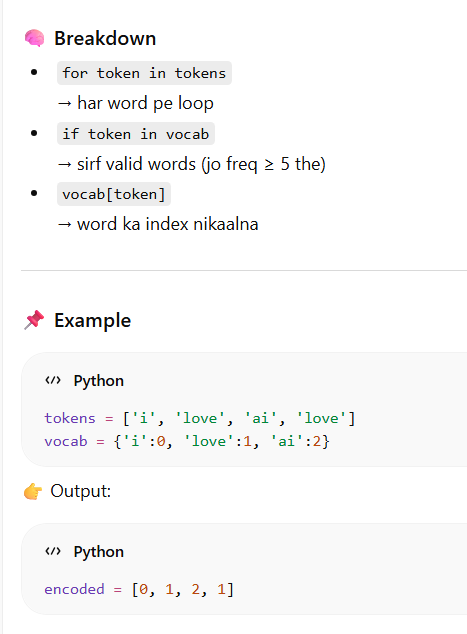

In [ ]:
encoded=[vocab[token] for token in tokens if token in vocab]

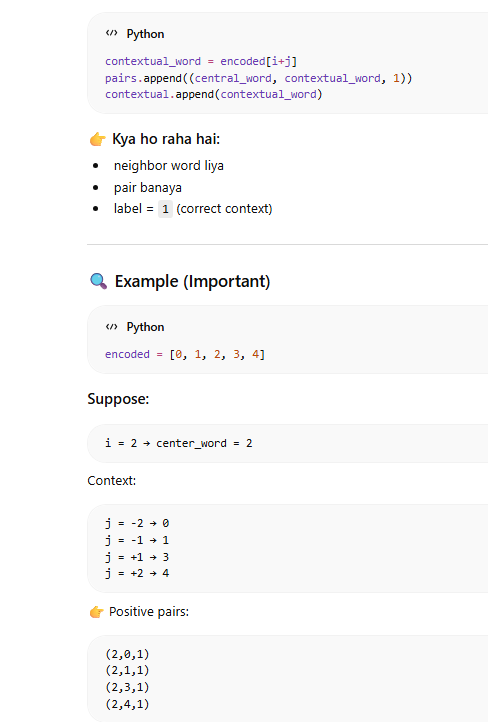

In [ ]:
import random
central_word=[]
pairs=[]
neg_words=1 #1 neg word per central word
#enumerate = index + value ek saath loop me
for i,central_word in enumerate(encoded):
    contextual=[]
    #context window=2
    for j in range(-2,3): #end not included
        if (j!=0 and 0<=i+j<len(encoded)):
            contextual_word=encoded[i+j]
            pairs.append((central_word,contextual_word,1))
            contextual.append(contextual_word)
    neg_count=0
    while (neg_count<neg_words): #jab tk req neg samples na mil jaye
        neg=random.randint(0,len(vocab)-1) #pick random ind from vocab
        if neg not in contextual: #ensure vo already contextual na ho
            pairs.append((central_word,neg,0))
            neg_count+=1


In [ ]:
import torch
torch.save({'vocab':vocab},'vocab_sgns.pth')
#PyTorch ka function hai jo Python object ko disk pe save karta hai
#File ka naam (extension .pth common hai PyTorch me)

#👉 Ye file save hogi current directory me

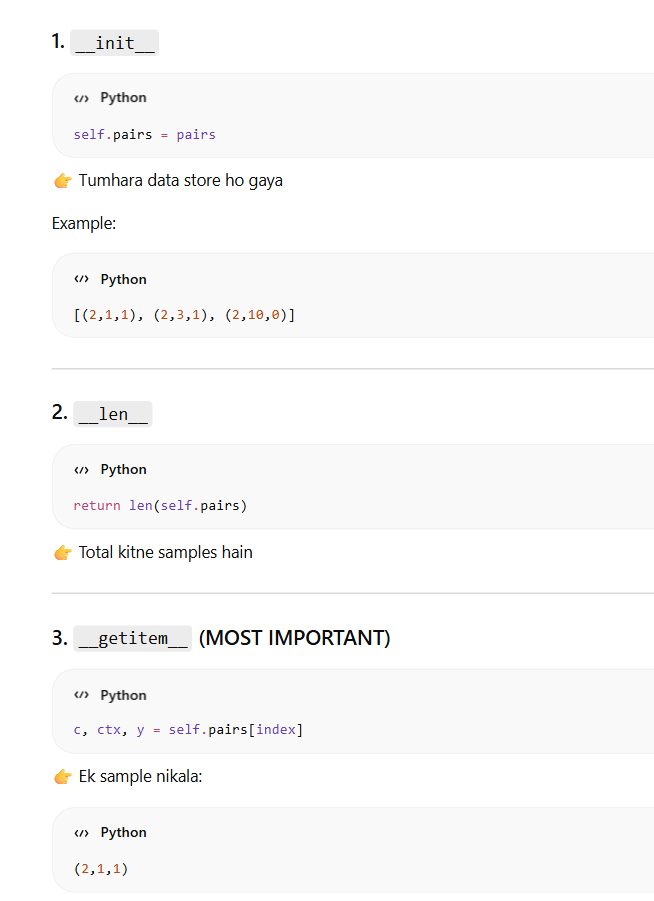

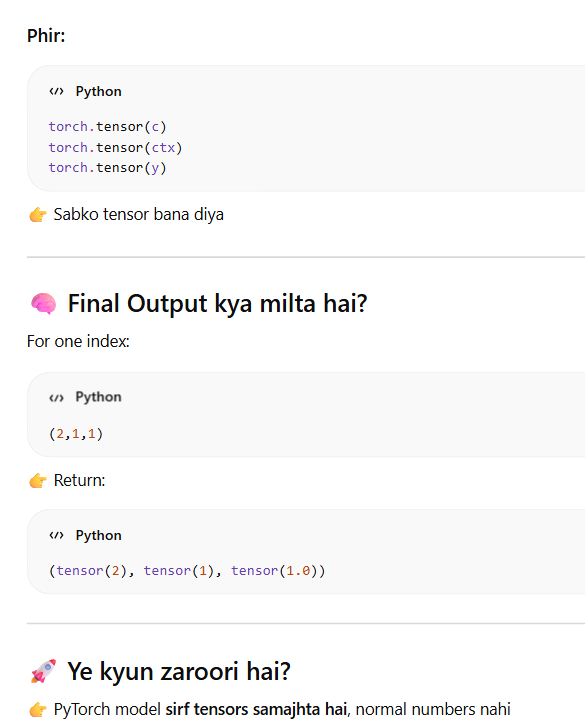

In [ ]:
class sgns_dataset(torch.utils.data.Dataset):
    def __init__(self,pairs):
        self.pairs=pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self,index):
        central,contextual,label=self.pairs[index]
        return torch.tensor(central),torch.tensor(contextual),torch.tensor(label,dtype=torch.float32)

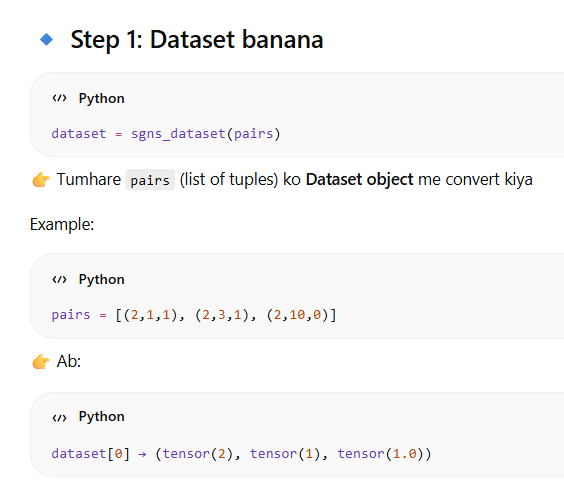

In [ ]:
dataset=sgns_dataset(pairs)

In [ ]:
loader=torch.utils.data.DataLoader(dataset,batch_size=1024,shuffle=True)

Har word ke 2 embeddings hote hain:  

W_hidden → center word embedding  

W_out → context word embedding

👉 Model seekhta hai:

“agar 2 words related hain → unka dot product high hona chahiye”

In [ ]:
import torch.nn as nn
class SGNSModel(torch.nn.Module):
    def __init__(self,vocab_size,output_dim):
        super(SGNSModel,self).__init__()
        self.W_hidden=nn.Parameter(torch.randn(vocab_size,output_dim)*0.01) # shape :[vocab_size, embedding_dim]
        self.W_out=nn.Parameter(torch.randn(vocab_size,output_dim)*0.01)
    def forward(self,central_ids,contextual_ids):
        v=self.W_hidden[central_ids]
        u=self.W_out[contextual_ids]
        score=torch.sum(v*u,dim=1)
        #prob=nn.Sigmoid(score)
        return score


But agar tum use kar rahe ho:

nn.BCEWithLogitsLoss()

👉 To sigmoid internally apply hota hai
👉 Isliye raw score return karna correct hai ✅

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
model=SGNSModel(len(vocab),100).to(device)

In [ ]:
optimizer=torch.optim.Adam(model.parameters())
loss_fn=nn.BCEWithLogitsLoss() #sigmoid + binary cross entropy

In [ ]:
epochs=5
from tqdm import tqdm
for epoch in range(epochs):
    loss=0
    model.train()
    loop=tqdm(loader,desc=f'Epoch {epoch+1}/{epochs}', leave=False)
    for (central_ids,contextual_ids,y_batch) in loop:
        optimizer.zero_grad() #purane gradients htao
        central_ids=central_ids.to(device)
        contextual_ids=contextual_ids.to(device)
        y_batch=y_batch.to(device)
        y_pred=model(central_ids,contextual_ids) #fwd pass
        batch_loss=loss_fn(y_pred,y_batch)
        batch_loss.backward()
        optimizer.step()
        loop.set_postfix(loss=batch_loss.item())
        loss+=batch_loss.item()
    print(f'Training loss over epoch {epoch+1} is {loss/len(loader)}')
    torch.save({'model_state_dict':model.state_dict(),
              'optimizer_state_dict':optimizer.state_dict(),
              'epoch':epoch+1,
               'loss':loss},f'checkpoint_{epoch}.pth'
              )

Training loss over epoch 1 is 0.21225876194176965


Training loss over epoch 2 is 0.18478886891174004


Training loss over epoch 3 is 0.16647583422111692


Training loss over epoch 4 is 0.15469531237352585


Training loss over epoch 5 is 0.14687254190766205


In [ ]:
embeddings1=model.W_hidden
embeddings2=model.W_out
embeddings=(embeddings1+embeddings2)/2
print(embeddings.shape)

torch.Size([71290, 100])


In [ ]:
torch.save(embeddings1,'embeddings_SGNS_hidden_5_epochs.pth')
torch.save(embeddings2,'embeddings_SGNS_output_5_epochs.pth')

In [ ]:
import pandas as pd
df=pd.read_csv('wordsim353.csv')

In [ ]:
import torch.nn.functional as F
sim=[]
for i in range(len(df)):
    word1=df['Word_1'][i]
    word2=df['Word_2'][i]
    if word1 in vocab and word2 in vocab:
        vec1=embeddings[vocab[word1]].unsqueeze(0)
        vec2=embeddings[vocab[word2]].unsqueeze(0)
        sim.append(F.cosine_similarity(vec1,vec2,dim=1).item())
    else:
        df=df.drop([i])


In [ ]:
df['model_score']=sim
import scipy
print(scipy.stats.spearmanr(df['score'],df['model_score']))

SignificanceResult(statistic=0.20715343942695785, pvalue=0.0001404578303079576)
